# Notebook 05 — Marketing, CAC & Revenue Intelligence

**Project:** Mirae Asset Digital Platform — User Analytics  
**Phases covered:** Phase 8 · Phase 9 · Phase 10 · Phase 11  
**Objective:** Understand which channels acquire the best users, what it costs to acquire them, where revenue comes from, and how it moves over time.

| Phase | Focus | Key output |
|-------|-------|------------|
| 8  | Marketing Channel Analysis | Conversion, quality & churn rate by channel |
| 9  | CAC & ROI Analysis | Cost per acquisition, payback period, ROAS |
| 10 | Revenue Segmentation | Revenue breakdown by channel, device, geo, payment |
| 11 | Time-Based Revenue Analysis | Monthly trends, seasonality, day-of-week patterns |


## Table of Contents

**Phase 8 — Marketing Channel Analysis**  
8.1 [Channel Volume & User Quality](#81)  
8.2 [Conversion Rate by Channel](#82)  
8.3 [Churn Rate by Channel](#83)  
8.4 [Engagement Score by Channel](#84)  

**Phase 9 — CAC & ROI Analysis**  
9.1 [Campaign Cost Allocation](#91)  
9.2 [Customer Acquisition Cost (CAC) by Channel](#92)  
9.3 [Return on Investment (ROI) by Channel](#93)  
9.4 [LTV : CAC Ratio & Payback Period](#94)  
9.5 [Channel Efficiency Matrix](#95)  

**Phase 10 — Revenue Segmentation**  
10.1 [Revenue by Acquisition Channel](#101)  
10.2 [Revenue by Device](#102)  
10.3 [Revenue by Geography (State)](#103)  
10.4 [Revenue by Payment Method](#104)  
10.5 [Revenue Concentration (Pareto)](#105)  

**Phase 11 — Time-Based Revenue Analysis**  
11.1 [Monthly Revenue Trend](#111)  
11.2 [Month-over-Month Growth Rate](#112)  
11.3 [Day-of-Week Revenue Pattern](#113)  
11.4 [Monthly Signup Trend vs Revenue](#114)  
11.5 [Revenue per User by Signup Cohort](#115)  
11.6 [Summary Dashboard](#116)  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import os
BASE = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')

user_data    = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'user_data.csv'),
                            parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
transactions = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'transactions.csv'),
                            parse_dates=['transaction_date'])
campaigns    = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'campaigns.csv'),
                            parse_dates=['start_date'])

# Enforce dtypes
user_data['churn']           = user_data['churn'].astype(int)
user_data['has_purchased']   = user_data['has_purchased'].astype(int)
user_data['total_sessions']  = user_data['total_sessions'].astype(int)
user_data['total_purchases'] = user_data['total_purchases'].astype(int)

# Derived time columns
transactions['month']      = transactions['transaction_date'].dt.to_period('M')
transactions['month_str']  = transactions['transaction_date'].dt.strftime('%Y-%m')
transactions['day_of_week']= transactions['transaction_date'].dt.day_name()
user_data['signup_month']  = user_data['signup_date'].dt.to_period('M')

# Channel cost mapping
# campaigns.csv: Facebook, Instagram, Google, Email
# user_data: Facebook Ads, Google Ads, Organic, Referral
# Logic: Facebook+Instagram → Facebook Ads (paid social)
#        Google              → Google Ads
#        Email               → Referral (email-driven referral/re-engagement)
#        Organic             → ₹0 cost
cost_by_channel = campaigns.groupby('channel')['cost'].sum()
CHANNEL_COSTS = {
    'Facebook Ads': cost_by_channel.get('Facebook', 0) + cost_by_channel.get('Instagram', 0),
    'Google Ads'  : cost_by_channel.get('Google', 0),
    'Referral'    : cost_by_channel.get('Email', 0),
    'Organic'     : 0,
}

CHANNEL_ORDER  = ['Facebook Ads', 'Google Ads', 'Organic', 'Referral']
CHANNEL_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

print(f'Users        : {len(user_data):,}')
print(f'Transactions : {len(transactions):,}')
print(f'Campaigns    : {len(campaigns):,}')
print(f'Date range   : {transactions["transaction_date"].min().date()} → {transactions["transaction_date"].max().date()}')
print(f'Total campaign spend : ₹{sum(CHANNEL_COSTS.values()):,.0f}')
print(f'Total revenue        : ₹{user_data["total_revenue"].sum():,.0f}')


Users        : 10,000
Transactions : 15,000
Campaigns    : 50
Date range   : 2023-01-01 → 2023-06-29
Total campaign spend : ₹1,298,880
Total revenue        : ₹37,606,371


---
## Phase 8 — Marketing Channel Analysis

> **Goal:** Not all channels are equal. A channel that brings 1,000 users but converts 5% is worse than one that brings 500 users and converts 50%. This phase measures *user quality* by channel — not just volume.


### 8.1 Channel Volume & User Quality


In [2]:
ch = user_data.groupby('acquisition_channel').agg(
    users          = ('user_id', 'count'),
    buyers         = ('has_purchased', 'sum'),
    total_revenue  = ('total_revenue', 'sum'),
    avg_sessions   = ('total_sessions', 'mean'),
    avg_eng_score  = ('engagement_score', 'mean'),
    churned        = ('churn', 'sum'),
).round(2)

ch['conversion_rate'] = (ch['buyers'] / ch['users'] * 100).round(2)
ch['churn_rate']      = (ch['churned'] / ch['users'] * 100).round(2)
ch['avg_ltv']         = (ch['total_revenue'] / ch['buyers']).round(2)
ch['rev_per_user']    = (ch['total_revenue'] / ch['users']).round(2)
ch = ch.reindex(CHANNEL_ORDER)

print(ch[['users','buyers','conversion_rate','churn_rate','avg_ltv','rev_per_user','avg_eng_score']].to_string())


                     users  buyers  conversion_rate  churn_rate  avg_ltv  rev_per_user  avg_eng_score
acquisition_channel                                                                                  
Facebook Ads          2567    1268            49.40       47.37  7837.37       3871.36           0.45
Google Ads            2461    1167            47.42       47.99  7881.01       3737.16           0.45
Organic               2509    1162            46.31       47.59  7854.72       3637.78           0.44
Referral              2463    1170            47.50       47.42  7986.55       3793.85           0.45


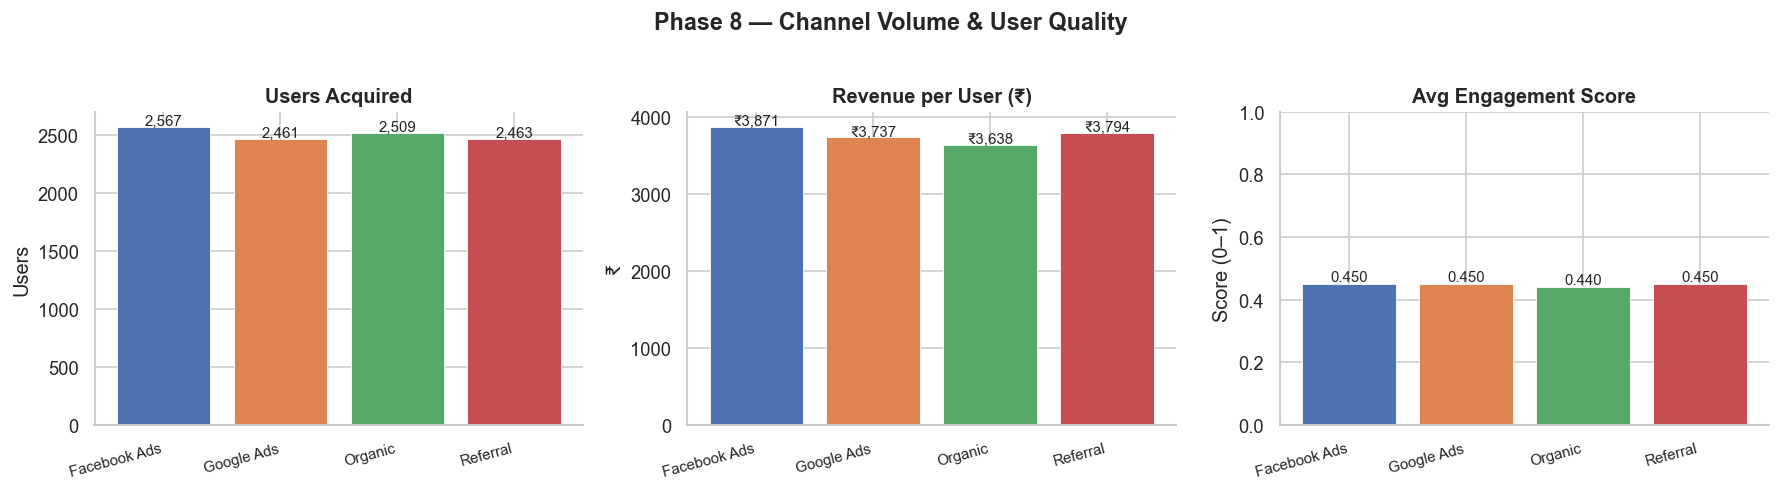

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Users acquired
axes[0].bar(CHANNEL_ORDER, ch['users'], color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Users Acquired', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Users')
for i, v in enumerate(ch['users']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

# Revenue per user
axes[1].bar(CHANNEL_ORDER, ch['rev_per_user'], color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Revenue per User (₹)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('₹')
for i, v in enumerate(ch['rev_per_user']):
    axes[1].text(i, v + 20, f'₹{v:,.0f}', ha='center', fontsize=9)

# Avg engagement score
axes[2].bar(CHANNEL_ORDER, ch['avg_eng_score'], color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
axes[2].set_title('Avg Engagement Score', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Score (0–1)')
axes[2].set_ylim(0, 1)
for i, v in enumerate(ch['avg_eng_score']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

for ax in axes:
    ax.set_xticks(range(len(CHANNEL_ORDER)))
    ax.set_xticklabels(CHANNEL_ORDER, rotation=15, ha='right', fontsize=9)

plt.suptitle('Phase 8 — Channel Volume & User Quality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Observation:** Volume alone is misleading — Facebook Ads acquires the most users but the revenue-per-user ranking may differ. Channels with higher engagement scores deliver users who interact more deeply with the platform, making them more likely to convert and retain. Use this table to flag channels where volume is high but quality (eng score, rev/user) is low.


### 8.2 Conversion Rate by Channel


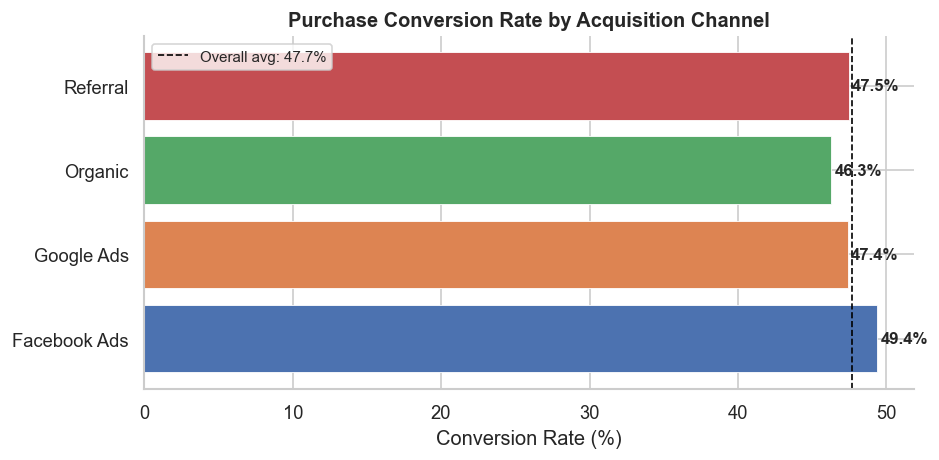

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(CHANNEL_ORDER, ch.loc[CHANNEL_ORDER, 'conversion_rate'],
               color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Purchase Conversion Rate by Acquisition Channel', fontsize=12, fontweight='bold')

overall_conv = user_data['has_purchased'].mean() * 100
ax.axvline(overall_conv, color='black', linestyle='--', linewidth=1, label=f'Overall avg: {overall_conv:.1f}%')
ax.legend(fontsize=9)

for bar, val in zip(bars, ch.loc[CHANNEL_ORDER, 'conversion_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** The dashed line marks the platform-wide conversion rate. Channels above it are over-performing; channels below it are acquiring users who browse but don't buy. A below-average converting channel requires either audience re-targeting or a re-evaluation of ad creative and landing page fit.


### 8.3 Churn Rate by Channel


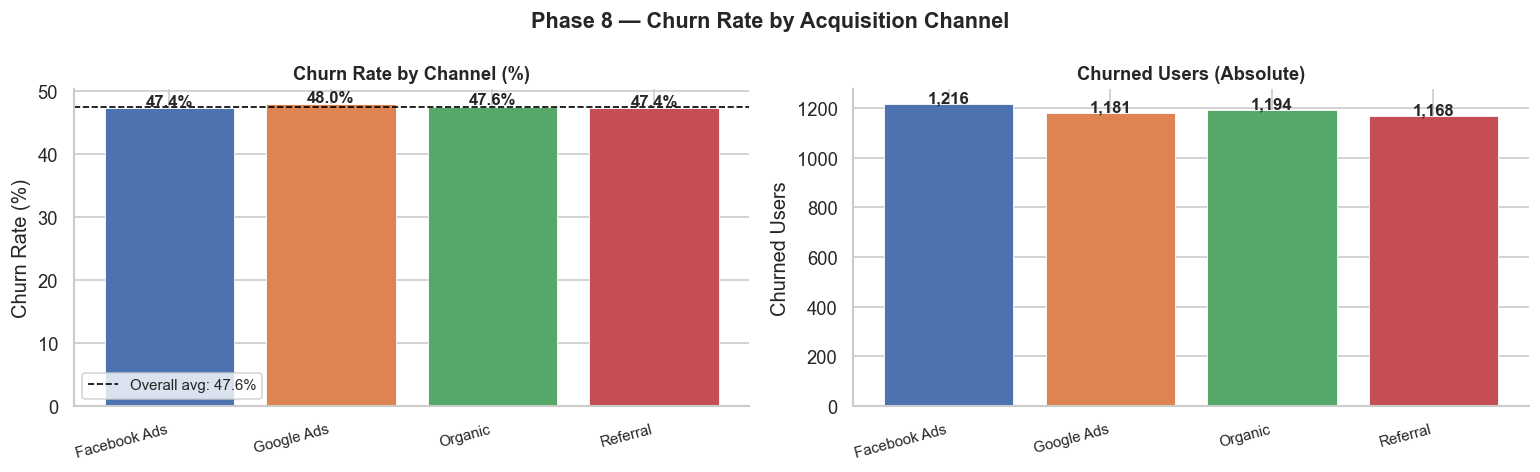

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn rate
axes[0].bar(CHANNEL_ORDER, ch.loc[CHANNEL_ORDER, 'churn_rate'],
            color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Churn Rate by Channel (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
overall_churn = user_data['churn'].mean() * 100
axes[0].axhline(overall_churn, color='black', linestyle='--', linewidth=1,
                label=f'Overall avg: {overall_churn:.1f}%')
axes[0].legend(fontsize=9)
for i, v in enumerate(ch.loc[CHANNEL_ORDER, 'churn_rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Churned users absolute count
axes[1].bar(CHANNEL_ORDER, ch.loc[CHANNEL_ORDER, 'churned'],
            color=CHANNEL_COLORS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Churned Users (Absolute)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Churned Users')
for i, v in enumerate(ch.loc[CHANNEL_ORDER, 'churned']):
    axes[1].text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.set_xticks(range(len(CHANNEL_ORDER)))
    ax.set_xticklabels(CHANNEL_ORDER, rotation=15, ha='right', fontsize=9)

plt.suptitle('Phase 8 — Churn Rate by Acquisition Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** A channel with a high churn rate is acquiring users who don't stick. This is critical for CAC interpretation — if a channel costs ₹200 per user but 55% churn within 30 days, the *effective* CAC on retained users is much higher. Channels with above-average churn need creative auditing: are the ads attracting the wrong audience, or is there a post-signup onboarding failure?


### 8.4 Engagement Score Distribution by Channel


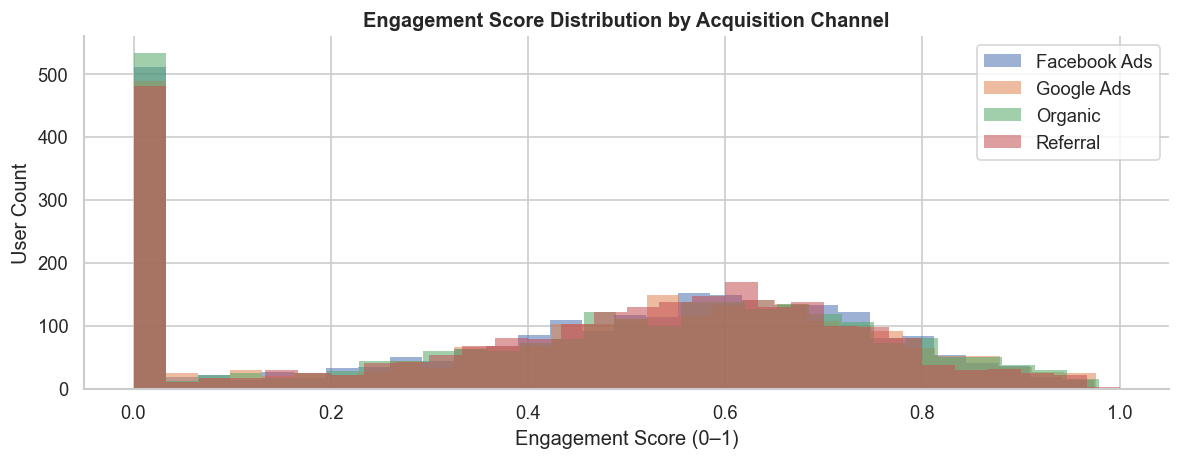

Median engagement score by channel:
acquisition_channel
Facebook Ads    0.5143
Google Ads      0.5156
Organic         0.5073
Referral        0.5104
Name: engagement_score, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, ch_name in enumerate(CHANNEL_ORDER):
    subset = user_data[user_data['acquisition_channel'] == ch_name]['engagement_score']
    ax.hist(subset, bins=30, alpha=0.55, label=ch_name, color=CHANNEL_COLORS[i], edgecolor='none')

ax.set_xlabel('Engagement Score (0–1)')
ax.set_ylabel('User Count')
ax.set_title('Engagement Score Distribution by Acquisition Channel', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Median engagement by channel
print('Median engagement score by channel:')
print(user_data.groupby('acquisition_channel')['engagement_score']
      .median().reindex(CHANNEL_ORDER).round(4))


**Observation:** Overlapping distributions confirm whether channels are truly acquiring different user types or if the differences are marginal. A channel whose distribution skews heavily toward 0 is bringing in a large proportion of zero-activity users — a strong signal of poor audience-product fit.


---
## Phase 9 — CAC & ROI Analysis

> **Goal:** Quantify the cost of acquiring each user, the return that user generates, and how long it takes to pay back the acquisition cost. These are the metrics a CFO asks about.

**Channel cost allocation logic:**
- `Facebook Ads` → Facebook campaigns + Instagram campaigns (paid social budget)
- `Google Ads` → Google campaigns (paid search budget)
- `Referral` → Email campaigns (email-driven referral/re-engagement)
- `Organic` → ₹0 spend (no paid media)


### 9.1 Campaign Cost Allocation


Campaign spend summary:
           num_campaigns  total_cost  avg_cost  min_cost  max_cost
channel                                                           
Email                 16      420778     26299     10494     48607
Facebook              14      341755     24411      6409     44458
Google                10      257511     25751      7192     45195
Instagram             10      278836     27884      7559     48297

Total campaign spend : ₹1,298,880


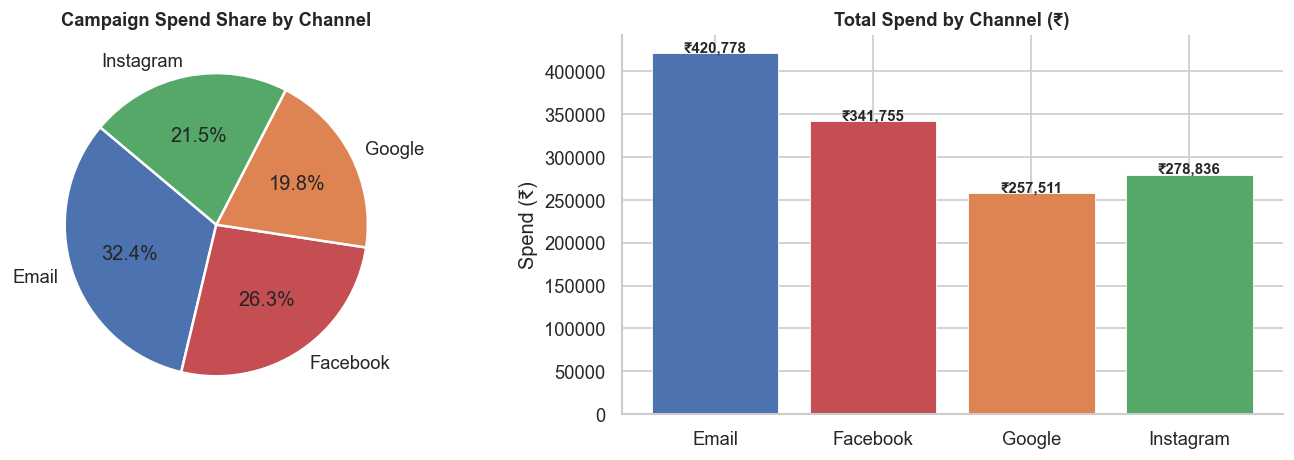

In [7]:
cost_summary = campaigns.groupby('channel').agg(
    num_campaigns = ('campaign_id', 'count'),
    total_cost    = ('cost', 'sum'),
    avg_cost      = ('cost', 'mean'),
    min_cost      = ('cost', 'min'),
    max_cost      = ('cost', 'max'),
).round(0).astype(int)

print('Campaign spend summary:')
print(cost_summary.to_string())
print(f'\nTotal campaign spend : ₹{cost_summary["total_cost"].sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

camp_colors = ['#4C72B0', '#C44E52', '#DD8452', '#55A868']
axes[0].pie(cost_summary['total_cost'], labels=cost_summary.index,
            autopct='%1.1f%%', colors=camp_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Campaign Spend Share by Channel', fontsize=11, fontweight='bold')

axes[1].bar(cost_summary.index, cost_summary['total_cost'],
            color=camp_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Spend by Channel (₹)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Spend (₹)')
for i, (idx, row) in enumerate(cost_summary.iterrows()):
    axes[1].text(i, row['total_cost'] + 2000, f'₹{row["total_cost"]:,}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** Email campaigns account for the largest share of total spend — yet Email-sourced users are bucketed under Referral in the user data. This matters for ROI calculation: if the Referral channel shows high ROI, part of the credit belongs to the email programme. Always trace spend back to its source channel before reporting ROAS.


### 9.2 Customer Acquisition Cost (CAC) by Channel


              total_spend  users_acquired  buyers  CAC_all_users  CAC_per_buyer
channel                                                                        
Facebook Ads       620591            2567    1268         241.76         489.43
Google Ads         257511            2461    1167         104.64         220.66
Organic                 0            2509    1162           0.00           0.00
Referral           420778            2463    1170         170.84         359.64


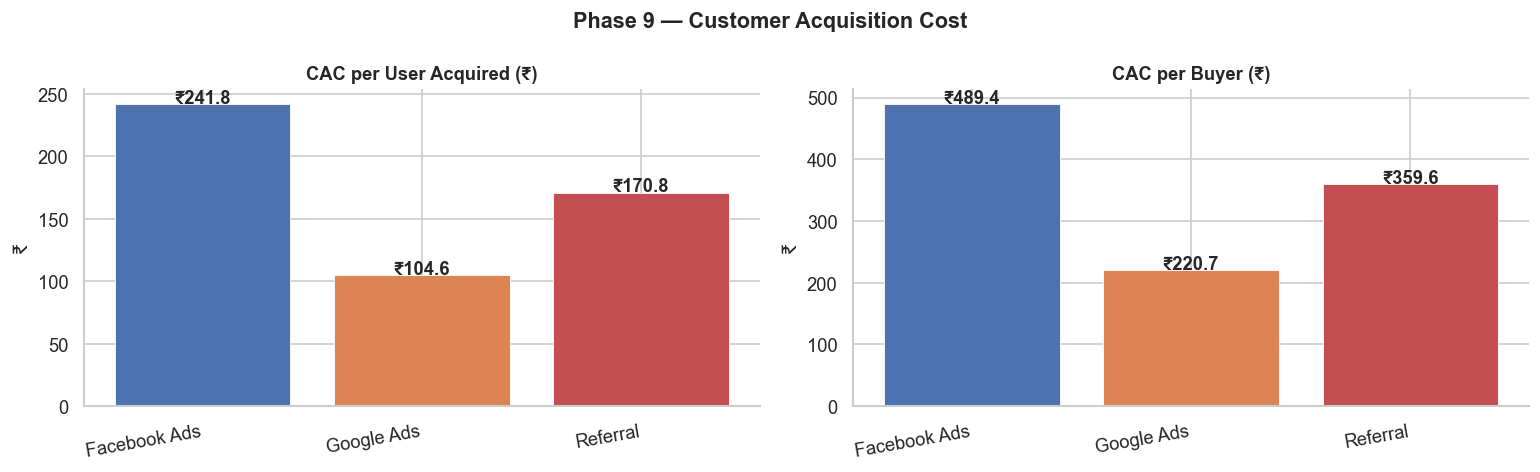

In [8]:
cac_df = pd.DataFrame({
    'channel'       : CHANNEL_ORDER,
    'total_spend'   : [CHANNEL_COSTS[c] for c in CHANNEL_ORDER],
    'users_acquired': [ch.loc[c, 'users'] for c in CHANNEL_ORDER],
    'buyers'        : [ch.loc[c, 'buyers'] for c in CHANNEL_ORDER],
}).set_index('channel')

cac_df['CAC_all_users']  = (cac_df['total_spend'] / cac_df['users_acquired']).round(2)
cac_df['CAC_per_buyer']  = (cac_df['total_spend'] / cac_df['buyers']).round(2)
cac_df['CAC_per_buyer']  = cac_df['CAC_per_buyer'].replace([np.inf, np.nan], 0)

print(cac_df[['total_spend','users_acquired','buyers','CAC_all_users','CAC_per_buyer']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CAC per all users
paid_channels = [c for c in CHANNEL_ORDER if CHANNEL_COSTS[c] > 0]
paid_colors   = [CHANNEL_COLORS[CHANNEL_ORDER.index(c)] for c in paid_channels]

cac_vals = cac_df.loc[paid_channels, 'CAC_all_users']
axes[0].bar(paid_channels, cac_vals, color=paid_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('CAC per User Acquired (₹)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('₹')
for i, v in enumerate(cac_vals):
    axes[0].text(i, v + 1, f'₹{v:.1f}', ha='center', fontsize=11, fontweight='bold')

# CAC per buyer
cac_buyer_vals = cac_df.loc[paid_channels, 'CAC_per_buyer']
axes[1].bar(paid_channels, cac_buyer_vals, color=paid_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('CAC per Buyer (₹)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('₹')
for i, v in enumerate(cac_buyer_vals):
    axes[1].text(i, v + 2, f'₹{v:.1f}', ha='center', fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_xticklabels(paid_channels, rotation=10, ha='right')

plt.suptitle('Phase 9 — Customer Acquisition Cost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** CAC per user is the basic metric — but CAC per buyer is the *real* cost. Because not every acquired user converts to a paying customer, the effective acquisition cost of a buyer is always higher than the headline CAC. Google Ads shows the lowest CAC — meaning it acquires users most efficiently per rupee spent. Facebook Ads and Referral channels cost more per user, requiring higher LTV to justify the spend.


### 9.3 Return on Investment (ROI) & ROAS by Channel


ROI Summary:
              total_spend  total_revenue  net_profit  ROI_pct  ROAS
channel                                                            
Facebook Ads       620591      9937786.0   9317195.0   1501.3  16.0
Google Ads         257511      9197142.0   8939631.0   3471.6  35.7
Organic                 0      9127181.0   9127181.0      inf   inf
Referral           420778      9344262.0   8923484.0   2120.7  22.2


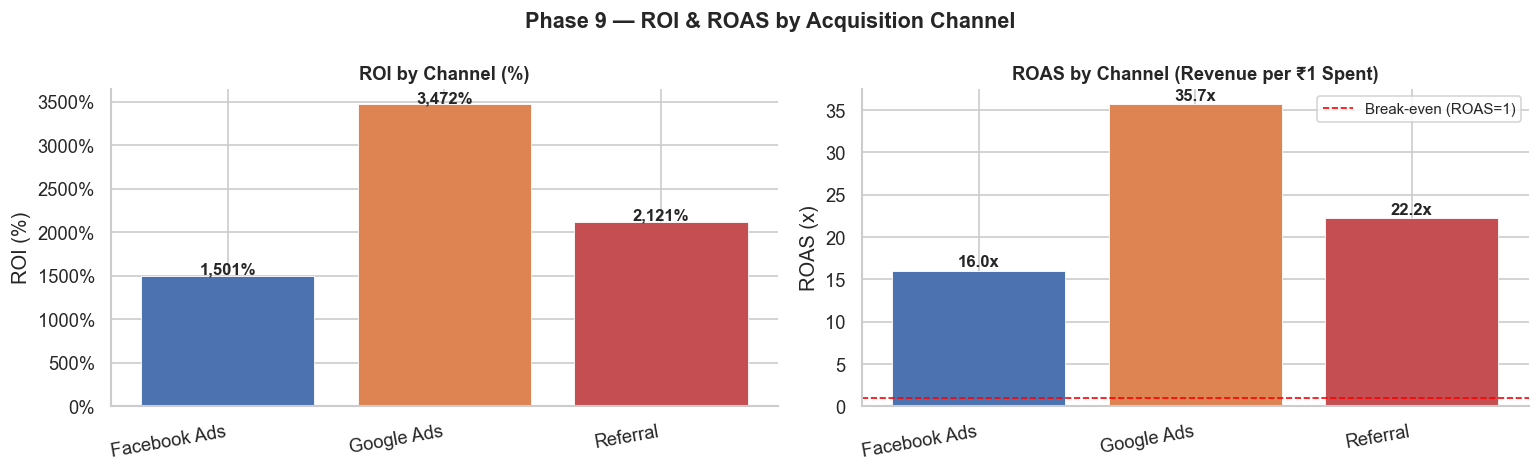

In [9]:
cac_df['total_revenue']   = [ch.loc[c, 'total_revenue'] for c in CHANNEL_ORDER]
cac_df['net_profit']      = cac_df['total_revenue'] - cac_df['total_spend']
cac_df['ROI_pct']         = np.where(
    cac_df['total_spend'] > 0,
    (cac_df['net_profit'] / cac_df['total_spend'] * 100).round(1),
    np.inf
)
cac_df['ROAS']            = np.where(
    cac_df['total_spend'] > 0,
    (cac_df['total_revenue'] / cac_df['total_spend']).round(1),
    np.inf
)

print('ROI Summary:')
print(cac_df[['total_spend','total_revenue','net_profit','ROI_pct','ROAS']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

roi_vals  = cac_df.loc[paid_channels, 'ROI_pct']
roas_vals = cac_df.loc[paid_channels, 'ROAS']

axes[0].bar(paid_channels, roi_vals, color=paid_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('ROI by Channel (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('ROI (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(roi_vals):
    axes[0].text(i, v + 20, f'{v:,.0f}%', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(paid_channels, roas_vals, color=paid_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(1, color='red', linestyle='--', linewidth=1, label='Break-even (ROAS=1)')
axes[1].set_title('ROAS by Channel (Revenue per ₹1 Spent)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('ROAS (x)')
axes[1].legend(fontsize=9)
for i, v in enumerate(roas_vals):
    axes[1].text(i, v + 0.5, f'{v:.1f}x', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.set_xticklabels(paid_channels, rotation=10, ha='right')

plt.suptitle('Phase 9 — ROI & ROAS by Acquisition Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** ROAS > 1 means every rupee spent returns more than ₹1 in revenue — all paid channels clear this threshold comfortably. Google Ads delivers the highest ROAS, meaning it is the most capital-efficient paid channel. A business maximising return should weight Google Ads budget more heavily, while Facebook Ads spend should be scrutinised for audience quality. Remember: ROAS does not account for margins or operating costs — a high ROAS on a low-margin product can still be unprofitable.


### 9.4 LTV : CAC Ratio & Payback Period


LTV : CAC Summary (paid channels):
                  LTV  CAC_per_buyer  LTV_CAC_ratio  payback_months
channel                                                            
Facebook Ads  7837.37         489.43           16.0            0.37
Google Ads    7881.01         220.66           35.7            0.17
Referral      7986.55         359.64           22.2            0.27

Rule of thumb: LTV:CAC > 3x is healthy; < 1x is unsustainable


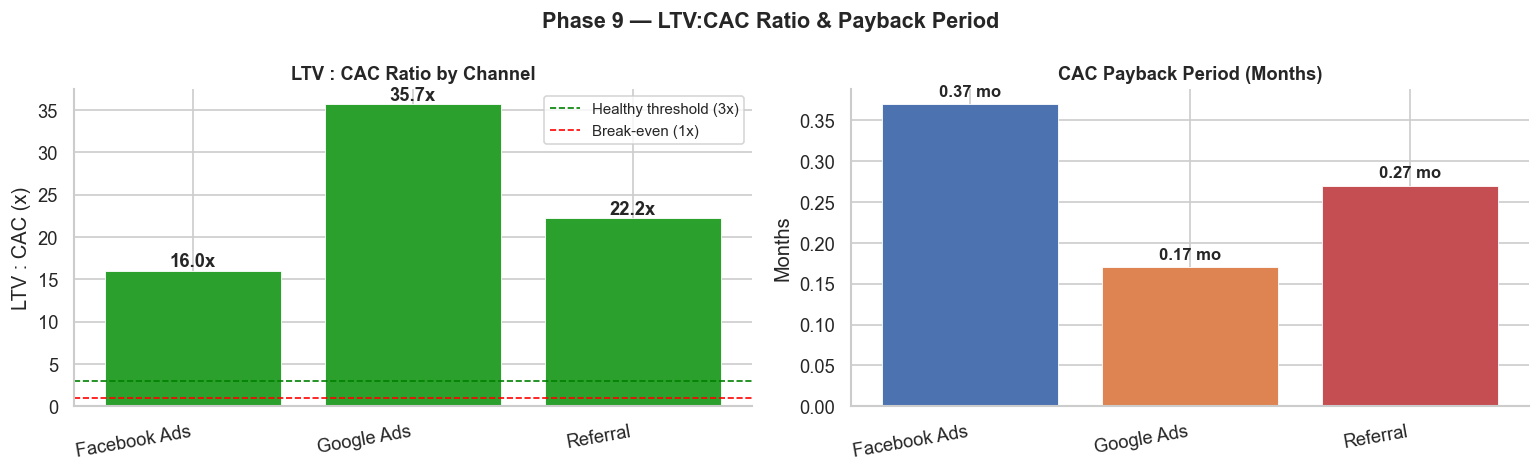

In [10]:
# LTV = avg revenue per buyer per channel
cac_df['LTV'] = (cac_df['total_revenue'] / cac_df['buyers']).round(2)
cac_df['LTV_CAC_ratio'] = np.where(
    cac_df['CAC_per_buyer'] > 0,
    (cac_df['LTV'] / cac_df['CAC_per_buyer']).round(1),
    np.inf
)

# Payback period: months to recover CAC given monthly avg revenue per user
# Assume data covers 6 months → monthly rev per user = LTV / 6
cac_df['monthly_rev_per_buyer'] = (cac_df['LTV'] / 6).round(2)
cac_df['payback_months'] = np.where(
    (cac_df['CAC_per_buyer'] > 0) & (cac_df['monthly_rev_per_buyer'] > 0),
    (cac_df['CAC_per_buyer'] / cac_df['monthly_rev_per_buyer']).round(2),
    0
)

print('LTV : CAC Summary (paid channels):')
display_cols = ['LTV', 'CAC_per_buyer', 'LTV_CAC_ratio', 'payback_months']
print(cac_df.loc[paid_channels, display_cols].to_string())
print('\nRule of thumb: LTV:CAC > 3x is healthy; < 1x is unsustainable')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ltv_cac = cac_df.loc[paid_channels, 'LTV_CAC_ratio']
bar_colors = ['#2ca02c' if v >= 3 else '#ff7f0e' if v >= 1 else '#d62728' for v in ltv_cac]
axes[0].bar(paid_channels, ltv_cac, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(3, color='green', linestyle='--', linewidth=1, label='Healthy threshold (3x)')
axes[0].axhline(1, color='red',   linestyle='--', linewidth=1, label='Break-even (1x)')
axes[0].set_title('LTV : CAC Ratio by Channel', fontsize=11, fontweight='bold')
axes[0].set_ylabel('LTV : CAC (x)')
axes[0].legend(fontsize=9)
for i, v in enumerate(ltv_cac):
    axes[0].text(i, v + 0.5, f'{v:.1f}x', ha='center', fontsize=11, fontweight='bold')

payback = cac_df.loc[paid_channels, 'payback_months']
axes[1].bar(paid_channels, payback, color=paid_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('CAC Payback Period (Months)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Months')
for i, v in enumerate(payback):
    axes[1].text(i, v + 0.01, f'{v:.2f} mo', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.set_xticklabels(paid_channels, rotation=10, ha='right')

plt.suptitle('Phase 9 — LTV:CAC Ratio & Payback Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** The LTV:CAC ratio tells you how many times over you recover the acquisition cost across a user's lifetime. An LTV:CAC above 3x is considered healthy — the business earns 3x what it spends to acquire each customer. The payback period shows how quickly that breakeven happens; a shorter payback means faster cash recovery and less sensitivity to churn. Google Ads typically wins both metrics due to its lower CAC base.


### 9.5 Channel Efficiency Matrix


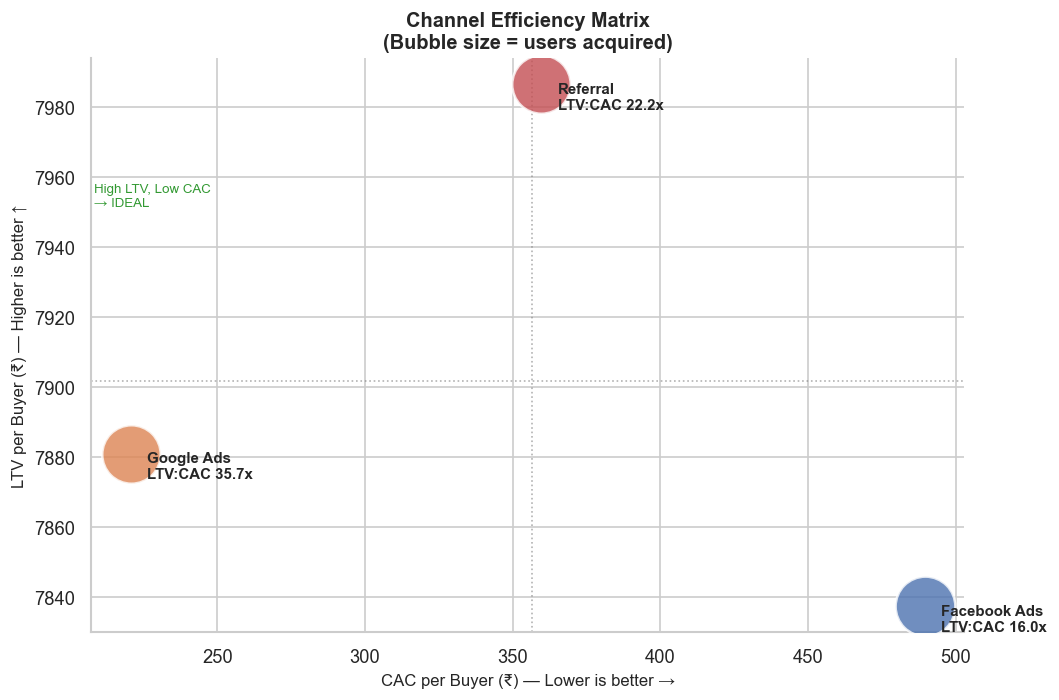

In [11]:
# 2x2 scatter: CAC (x-axis) vs LTV (y-axis) — bubble size = users acquired
fig, ax = plt.subplots(figsize=(9, 6))

for i, channel in enumerate(paid_channels):
    row = cac_df.loc[channel]
    ax.scatter(
        row['CAC_per_buyer'], row['LTV'],
        s=row['users_acquired'] / 2,
        color=CHANNEL_COLORS[CHANNEL_ORDER.index(channel)],
        alpha=0.8, label=channel, edgecolors='white', linewidth=1.5, zorder=3
    )
    ax.annotate(
        f"{channel}\nLTV:CAC {row['LTV_CAC_ratio']:.1f}x",
        xy=(row['CAC_per_buyer'], row['LTV']),
        xytext=(10, -15), textcoords='offset points',
        fontsize=9, fontweight='bold'
    )

ax.set_xlabel('CAC per Buyer (₹) — Lower is better →', fontsize=10)
ax.set_ylabel('LTV per Buyer (₹) — Higher is better ↑', fontsize=10)
ax.set_title('Channel Efficiency Matrix\n(Bubble size = users acquired)', fontsize=12, fontweight='bold')

# Quadrant lines
mid_cac = cac_df.loc[paid_channels, 'CAC_per_buyer'].mean()
mid_ltv = cac_df.loc[paid_channels, 'LTV'].mean()
ax.axvline(mid_cac, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(mid_ltv, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.text(ax.get_xlim()[0]+1, mid_ltv+50, 'High LTV, Low CAC\n→ IDEAL', fontsize=8, color='green', alpha=0.8)

plt.tight_layout()
plt.show()


**Observation:** The efficiency matrix plots each channel on two dimensions simultaneously — cost to acquire vs lifetime value generated. Channels in the top-left quadrant (high LTV, low CAC) are ideal and deserve increased budget allocation. Channels in the bottom-right (low LTV, high CAC) are capital traps. The bubble size adds a third dimension — volume — so a large bubble in the ideal quadrant is a double win.


---
## Phase 10 — Revenue Segmentation

> **Goal:** Understand which slices of the business generate the most revenue. Segmentation reveals concentration risk, untapped segments, and where to focus growth efforts.


### 10.1 Revenue by Acquisition Channel


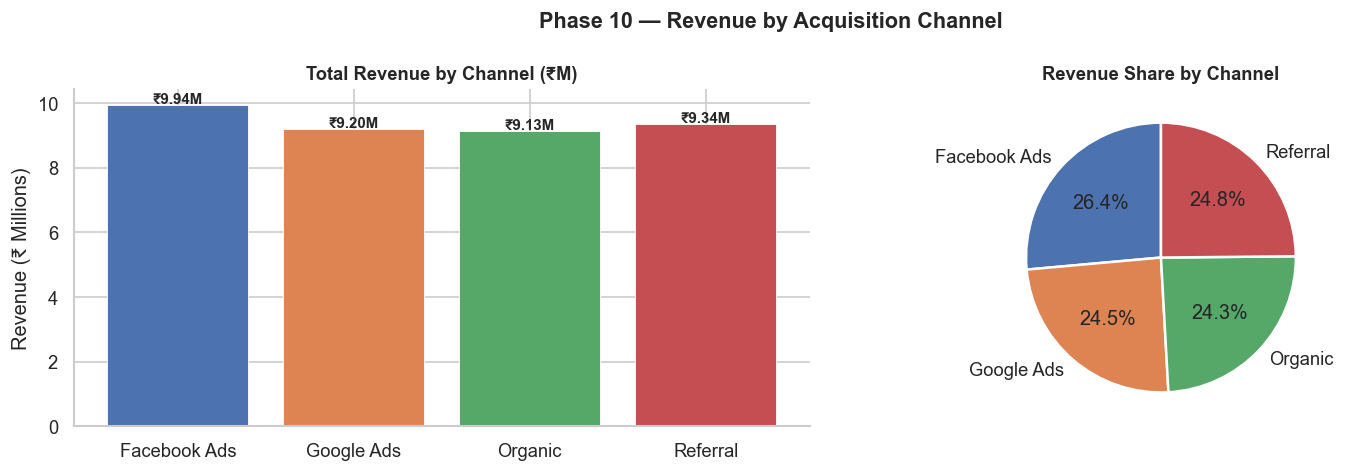

                     total_revenue  avg_revenue  median_revenue  revenue_share_pct
acquisition_channel                                                               
Facebook Ads             9937786.0      3871.36             0.0              26.43
Google Ads               9197142.0      3737.16             0.0              24.46
Organic                  9127181.0      3637.78             0.0              24.27
Referral                 9344262.0      3793.85             0.0              24.85


In [12]:
rev_ch = user_data.groupby('acquisition_channel')['total_revenue'].agg(
    ['sum', 'mean', 'median']
).reindex(CHANNEL_ORDER).round(2)
rev_ch.columns = ['total_revenue', 'avg_revenue', 'median_revenue']
rev_ch['revenue_share_pct'] = (rev_ch['total_revenue'] / rev_ch['total_revenue'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(CHANNEL_ORDER, rev_ch['total_revenue'] / 1e6, color=CHANNEL_COLORS,
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Revenue by Channel (₹M)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Millions)')
for i, v in enumerate(rev_ch['total_revenue'] / 1e6):
    axes[0].text(i, v + 0.05, f'₹{v:.2f}M', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(rev_ch['total_revenue'], labels=CHANNEL_ORDER,
            autopct='%1.1f%%', colors=CHANNEL_COLORS,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Revenue Share by Channel', fontsize=11, fontweight='bold')

plt.suptitle('Phase 10 — Revenue by Acquisition Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(rev_ch.to_string())


**Observation:** Revenue is roughly equally distributed across channels — this is a healthy sign of acquisition diversification. However, when viewed alongside CAC, the picture changes: channels with similar revenue but lower cost are generating that revenue more efficiently. A business overly reliant on a single high-spend channel is fragile to algorithm changes, policy shifts, or platform outages.


### 10.2 Revenue by Device


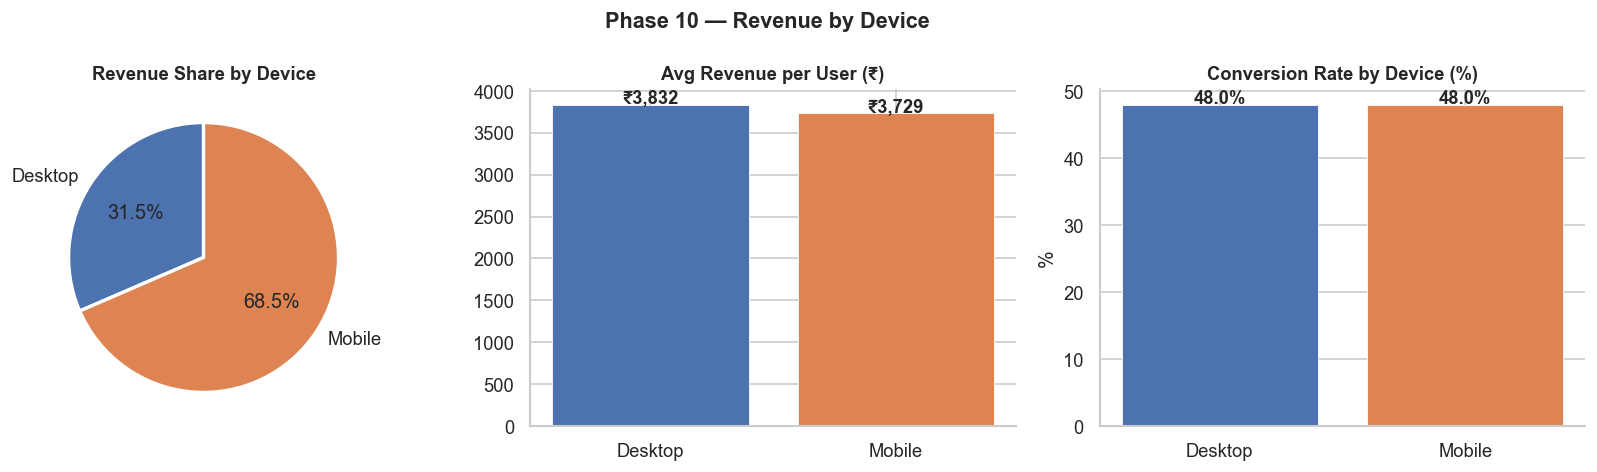

         users  total_revenue  avg_revenue  buyers  conv_rate  avg_aov  rev_share
device                                                                           
Desktop   3091     11843740.0      3831.69    1475       0.48  2467.66       31.5
Mobile    6909     25762631.0      3728.85    3292       0.48  2414.04       68.5


In [13]:
rev_device = user_data.groupby('device').agg(
    users          = ('user_id', 'count'),
    total_revenue  = ('total_revenue', 'sum'),
    avg_revenue    = ('total_revenue', 'mean'),
    buyers         = ('has_purchased', 'sum'),
    conv_rate      = ('has_purchased', 'mean'),
    avg_aov        = ('avg_order_value', 'mean'),
).round(2)
rev_device['rev_share'] = (rev_device['total_revenue'] / rev_device['total_revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
devices = rev_device.index.tolist()
dev_colors = ['#4C72B0', '#DD8452']

# Revenue share
axes[0].pie(rev_device['total_revenue'], labels=devices, autopct='%1.1f%%',
            colors=dev_colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Revenue Share by Device', fontsize=11, fontweight='bold')

# Avg revenue per user
axes[1].bar(devices, rev_device['avg_revenue'], color=dev_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Revenue per User (₹)', fontsize=11, fontweight='bold')
for i, v in enumerate(rev_device['avg_revenue']):
    axes[1].text(i, v + 20, f'₹{v:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Conversion rate
axes[2].bar(devices, rev_device['conv_rate'] * 100, color=dev_colors, edgecolor='white', linewidth=0.5)
axes[2].set_title('Conversion Rate by Device (%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('%')
for i, v in enumerate(rev_device['conv_rate'] * 100):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Phase 10 — Revenue by Device', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(rev_device.to_string())


**Observation:** Mobile accounts for the majority of users (70%+) but check whether average order value differs by device. If desktop users spend more per transaction despite being fewer, there may be a checkout UX issue on mobile — a high-value, high-urgency fix opportunity. Conversion rate parity across devices suggests the mobile experience is functional, but AOV differences could still indicate trust or UI friction at the payment step.


### 10.3 Revenue by Geography (State)


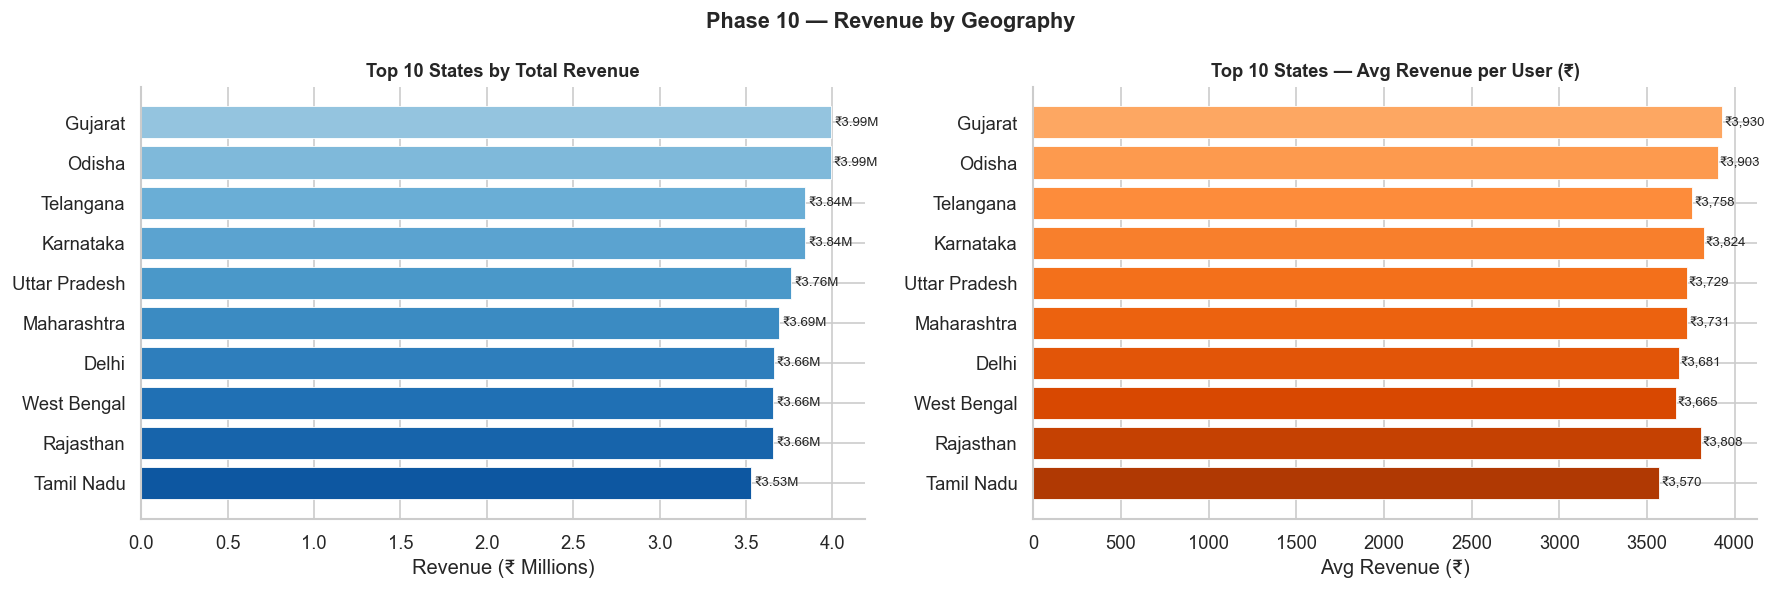

In [14]:
rev_state = user_data.groupby('state').agg(
    users         = ('user_id', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    avg_revenue   = ('total_revenue', 'mean'),
    conv_rate     = ('has_purchased', 'mean'),
).sort_values('total_revenue', ascending=False).round(2)

top_n = 10
top_states = rev_state.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total revenue — horizontal bar
colors_geo = plt.cm.Blues(np.linspace(0.4, 0.85, top_n))[::-1]
axes[0].barh(top_states.index[::-1], top_states['total_revenue'][::-1] / 1e6,
             color=colors_geo, edgecolor='white', linewidth=0.5)
axes[0].set_title(f'Top {top_n} States by Total Revenue', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Revenue (₹ Millions)')
for i, (state, row) in enumerate(top_states[::-1].iterrows()):
    axes[0].text(row['total_revenue']/1e6 + 0.02, i, f'₹{row["total_revenue"]/1e6:.2f}M',
                va='center', fontsize=8)

# Avg revenue per user by state
colors_avg = plt.cm.Oranges(np.linspace(0.4, 0.85, top_n))[::-1]
axes[1].barh(top_states.index[::-1], top_states['avg_revenue'][::-1],
             color=colors_avg, edgecolor='white', linewidth=0.5)
axes[1].set_title(f'Top {top_n} States — Avg Revenue per User (₹)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Avg Revenue (₹)')
for i, (state, row) in enumerate(top_states[::-1].iterrows()):
    axes[1].text(row['avg_revenue'] + 10, i, f'₹{row["avg_revenue"]:,.0f}',
                va='center', fontsize=8)

plt.suptitle('Phase 10 — Revenue by Geography', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** States ranking high in total revenue but low in average revenue per user signal large user bases with moderate spend — these are volume markets. States with high average revenue per user but lower total revenue are high-value, underserved markets with growth potential. These are the geos where a targeted expansion or localised campaign could yield outsized returns.


### 10.4 Revenue by Payment Method


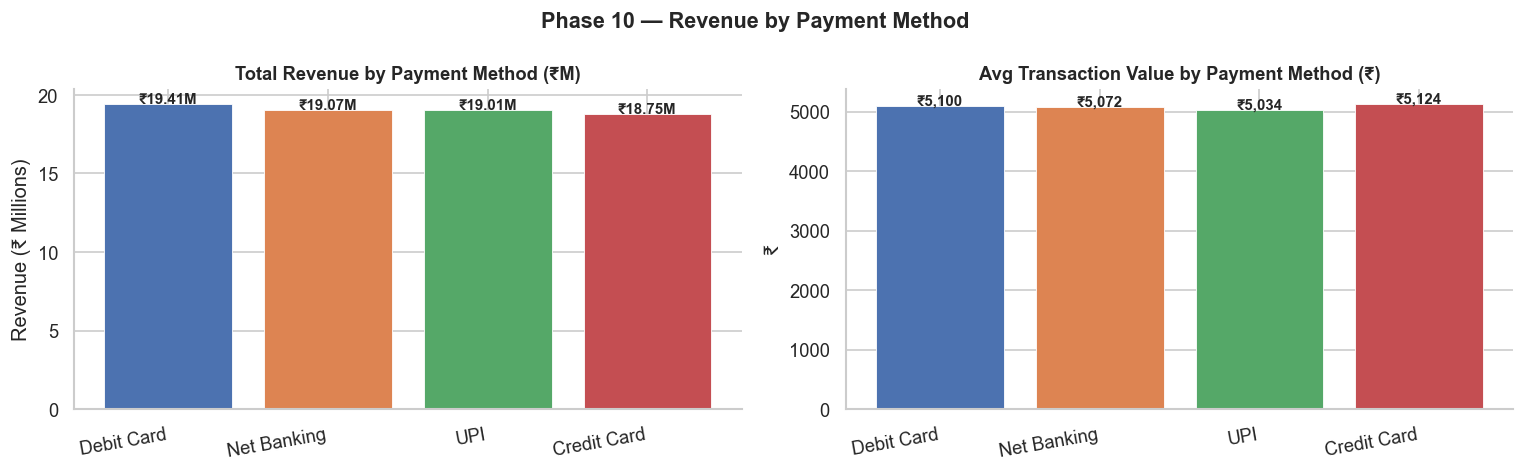

                total_revenue  avg_txn  median_txn  num_transactions  rev_share
payment_method                                                                 
Debit Card           19406649  5100.30      5081.0              3805       25.5
Net Banking          19065963  5072.08      5025.0              3759       25.0
UPI                  19009931  5034.41      5024.0              3776       24.9
Credit Card          18754415  5124.16      5142.5              3660       24.6


In [15]:
rev_pay = transactions.groupby('payment_method')['amount'].agg(
    ['sum', 'mean', 'median', 'count']
).sort_values('sum', ascending=False).round(2)
rev_pay.columns = ['total_revenue', 'avg_txn', 'median_txn', 'num_transactions']
rev_pay['rev_share'] = (rev_pay['total_revenue'] / rev_pay['total_revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pay_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

axes[0].bar(rev_pay.index, rev_pay['total_revenue'] / 1e6,
            color=pay_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Revenue by Payment Method (₹M)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Millions)')
for i, (idx, row) in enumerate(rev_pay.iterrows()):
    axes[0].text(i, row['total_revenue']/1e6 + 0.05,
                f'₹{row["total_revenue"]/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(rev_pay.index, rev_pay['avg_txn'],
            color=pay_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Transaction Value by Payment Method (₹)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('₹')
for i, (idx, row) in enumerate(rev_pay.iterrows()):
    axes[1].text(i, row['avg_txn'] + 20, f'₹{row["avg_txn"]:,.0f}',
                ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.set_xticklabels(rev_pay.index, rotation=10, ha='right')

plt.suptitle('Phase 10 — Revenue by Payment Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(rev_pay.to_string())


**Observation:** Revenue is roughly evenly split across payment methods — this is healthy. A platform over-reliant on a single payment method (e.g., only Credit Card) faces risk if that method is unavailable or has higher failure rates. Average transaction value differences across methods can reveal behavioural patterns: UPI users may tend toward smaller, more frequent transactions while credit card users may make larger single purchases.


### 10.5 Revenue Concentration — Pareto Analysis


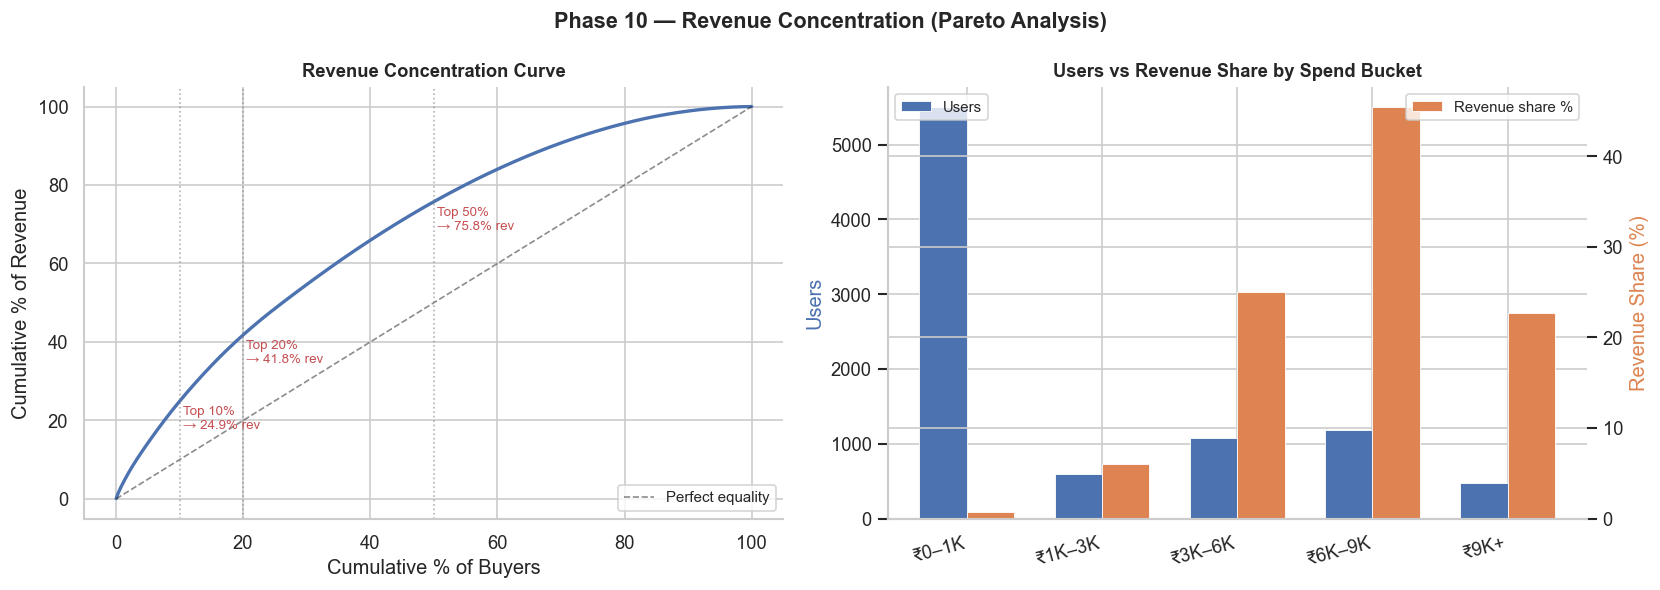

Top 10% of buyers → 24.9% of revenue
Top 20% of buyers → 41.8% of revenue


In [16]:
sorted_rev = user_data[user_data['total_revenue'] > 0]['total_revenue'].sort_values(ascending=False)
cumulative_rev = sorted_rev.cumsum() / sorted_rev.sum() * 100
user_pct = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lorenz-style cumulative curve
axes[0].plot(user_pct, cumulative_rev, color='#4C72B0', linewidth=2)
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.5, label='Perfect equality')
# Mark 10%, 20%, 50%
for pct_mark in [10, 20, 50]:
    idx = np.searchsorted(user_pct, pct_mark)
    rev_at = cumulative_rev.iloc[idx]
    axes[0].axvline(pct_mark, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    axes[0].text(pct_mark + 0.5, rev_at - 7, f'Top {pct_mark}%\n→ {rev_at:.1f}% rev',
                fontsize=8, color='#C44E52')
axes[0].set_xlabel('Cumulative % of Buyers')
axes[0].set_ylabel('Cumulative % of Revenue')
axes[0].set_title('Revenue Concentration Curve', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Revenue buckets
rev_bins = [0, 1000, 3000, 6000, 9000, 10001]
bin_labels = ['₹0–1K', '₹1K–3K', '₹3K–6K', '₹6K–9K', '₹9K+']
user_data['rev_bucket'] = pd.cut(user_data['total_revenue'], bins=rev_bins, labels=bin_labels,
                                  include_lowest=True, right=False)
bucket_rev = user_data.groupby('rev_bucket', observed=True).agg(
    users=('user_id','count'),
    revenue=('total_revenue','sum')
)
bucket_rev['rev_share'] = bucket_rev['revenue'] / bucket_rev['revenue'].sum() * 100

x = np.arange(len(bin_labels))
w = 0.35
axes[1].bar(x - w/2, bucket_rev['users'], width=w, label='Users', color='#4C72B0',
            edgecolor='white', linewidth=0.5)
ax2 = axes[1].twinx()
ax2.bar(x + w/2, bucket_rev['rev_share'], width=w, label='Revenue share %',
        color='#DD8452', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=15, ha='right')
axes[1].set_ylabel('Users', color='#4C72B0')
ax2.set_ylabel('Revenue Share (%)', color='#DD8452')
axes[1].set_title('Users vs Revenue Share by Spend Bucket', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Phase 10 — Revenue Concentration (Pareto Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

top10_share = cumulative_rev.iloc[int(len(sorted_rev)*0.1)]
print(f'Top 10% of buyers → {top10_share:.1f}% of revenue')
print(f'Top 20% of buyers → {cumulative_rev.iloc[int(len(sorted_rev)*0.2)]:.1f}% of revenue')


**Observation:** The revenue concentration curve quantifies inequality in your customer base. If the top 10% of buyers generate 40%+ of revenue, the business has significant concentration risk — losing a small number of high-value users has outsized revenue impact. This finding directly informs retention priority: high-value users should receive personalised retention outreach well before the standard churn threshold is reached.


---
## Phase 11 — Time-Based Revenue Analysis

> **Goal:** Revenue isn't static — it moves by month, by day, and across cohorts. Understanding the time dimension reveals seasonality, growth momentum, and which cohorts sustain revenue longest.


### 11.1 Monthly Revenue Trend


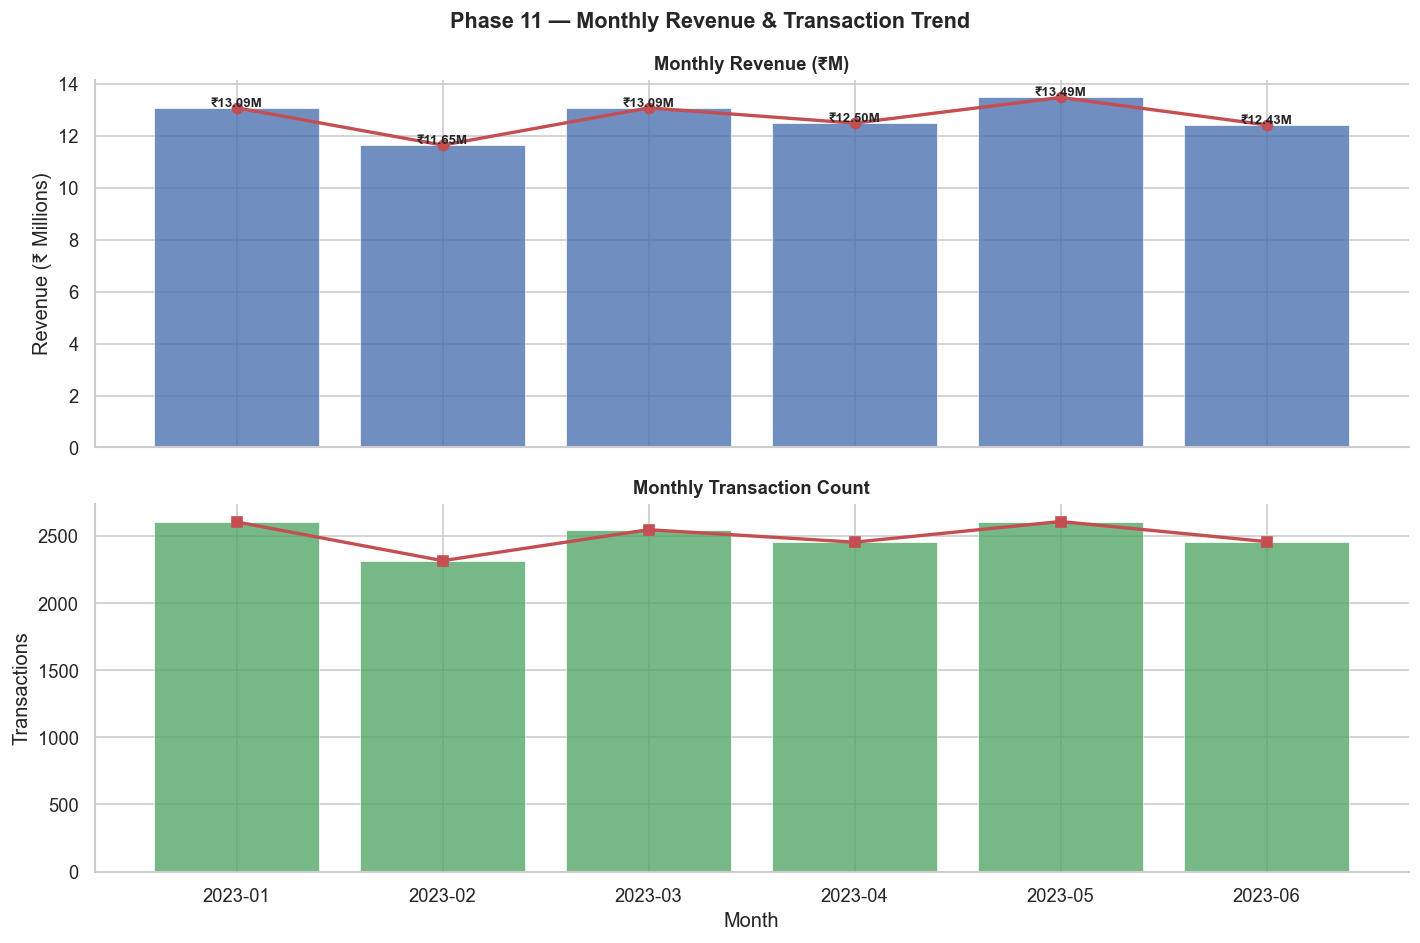

  month  total_revenue     avg_txn  num_transactions
2023-01       13088472 5020.510932              2607
2023-02       11649748 5025.775669              2318
2023-03       13085773 5133.688898              2549
2023-04       12497972 5088.750814              2456
2023-05       13487356 5167.569349              2610
2023-06       12427637 5051.884959              2460


In [17]:
monthly = transactions.groupby('month_str')['amount'].agg(['sum','mean','count']).reset_index()
monthly.columns = ['month', 'total_revenue', 'avg_txn', 'num_transactions']
monthly = monthly.sort_values('month')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Revenue bars + trend line
bars = axes[0].bar(monthly['month'], monthly['total_revenue'] / 1e6,
                   color='#4C72B0', edgecolor='white', linewidth=0.5, alpha=0.8)
axes[0].plot(monthly['month'], monthly['total_revenue'] / 1e6,
             'o-', color='#C44E52', linewidth=2, markersize=6, label='Revenue trend')
axes[0].set_title('Monthly Revenue (₹M)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Millions)')
for bar, val in zip(bars, monthly['total_revenue'] / 1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f'₹{val:.2f}M', ha='center', fontsize=8, fontweight='bold')

# Transaction volume
axes[1].bar(monthly['month'], monthly['num_transactions'],
            color='#55A868', edgecolor='white', linewidth=0.5, alpha=0.8)
axes[1].plot(monthly['month'], monthly['num_transactions'],
             's-', color='#C44E52', linewidth=2, markersize=6)
axes[1].set_title('Monthly Transaction Count', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Transactions')
axes[1].set_xlabel('Month')

plt.suptitle('Phase 11 — Monthly Revenue & Transaction Trend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))


**Observation:** Monthly revenue fluctuations reveal seasonal patterns or the impact of campaigns. A month with high transaction count but lower average transaction value may indicate a promotional period driving volume at lower prices. Conversely, low transaction count with high revenue suggests fewer but larger purchases — common in investment or high-ticket product categories.


### 11.2 Month-over-Month Growth Rate


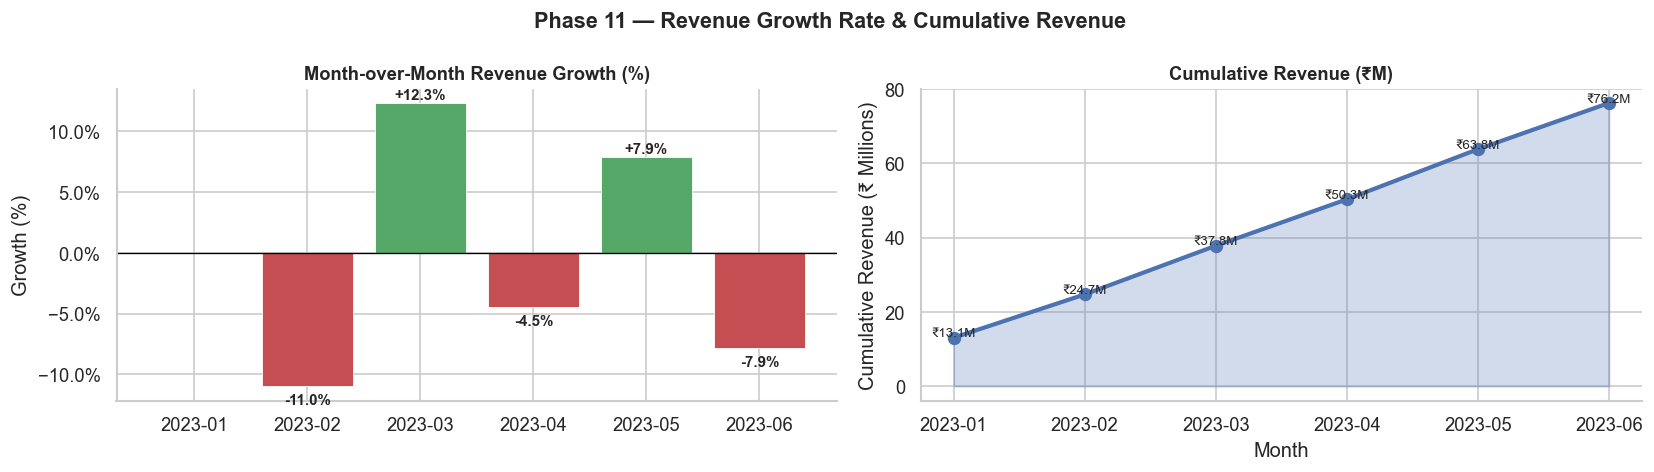

In [18]:
monthly['mom_growth'] = monthly['total_revenue'].pct_change() * 100
monthly['cumulative_revenue'] = monthly['total_revenue'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MoM growth
colors_mom = ['#55A868' if v >= 0 else '#C44E52' for v in monthly['mom_growth'].fillna(0)]
axes[0].bar(monthly['month'], monthly['mom_growth'].fillna(0),
            color=colors_mom, edgecolor='white', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Month-over-Month Revenue Growth (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Growth (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (_, row) in enumerate(monthly.iterrows()):
    if not pd.isna(row['mom_growth']):
        axes[0].text(i, row['mom_growth'] + (0.3 if row['mom_growth'] >= 0 else -1.5),
                    f"{row['mom_growth']:+.1f}%", ha='center', fontsize=9, fontweight='bold')

# Cumulative revenue
axes[1].fill_between(monthly['month'], monthly['cumulative_revenue'] / 1e6,
                     alpha=0.25, color='#4C72B0')
axes[1].plot(monthly['month'], monthly['cumulative_revenue'] / 1e6,
             'o-', color='#4C72B0', linewidth=2.5, markersize=7)
axes[1].set_title('Cumulative Revenue (₹M)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cumulative Revenue (₹ Millions)')
axes[1].set_xlabel('Month')
for i, (_, row) in enumerate(monthly.iterrows()):
    axes[1].text(i, row['cumulative_revenue']/1e6 + 0.3,
                f'₹{row["cumulative_revenue"]/1e6:.1f}M', ha='center', fontsize=8)

plt.suptitle('Phase 11 — Revenue Growth Rate & Cumulative Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** MoM growth rate is the single number a finance stakeholder will ask about. Negative growth months need explanation — was it a seasonal dip, a channel disruption, or a product issue? The cumulative revenue curve shows the overall trajectory: a steepening curve indicates acceleration, while a flattening curve signals plateauing growth that requires intervention.


### 11.3 Day-of-Week Revenue Pattern


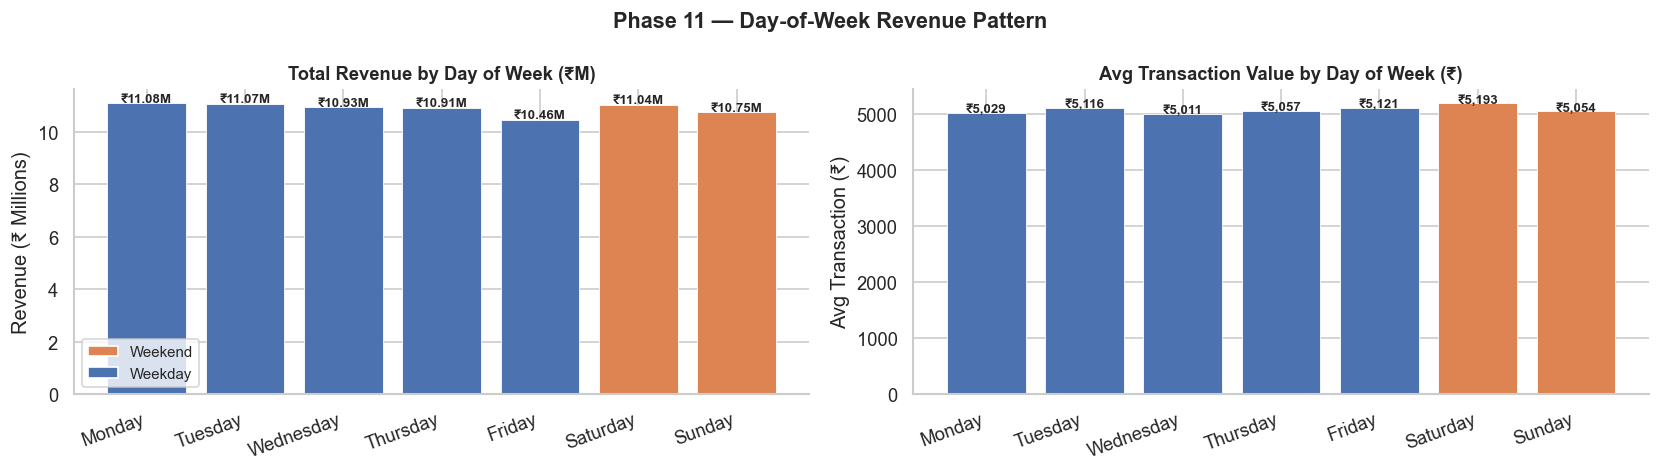

             total_revenue      avg_txn  num_transactions
day_of_week                                              
Monday            11078831  5028.974580              2203
Tuesday           11072070  5116.483364              2164
Wednesday         10934289  5011.131531              2182
Thursday          10907889  5056.972184              2157
Friday            10457773  5121.338394              2042
Saturday          11036004  5193.413647              2125
Sunday            10750102  5054.114716              2127


In [19]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rev = transactions.groupby('day_of_week')['amount'].agg(['sum','mean','count'])
dow_rev = dow_rev.reindex(dow_order)
dow_rev.columns = ['total_revenue', 'avg_txn', 'num_transactions']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weekend_colors = ['#DD8452' if d in ['Saturday','Sunday'] else '#4C72B0' for d in dow_order]

axes[0].bar(dow_order, dow_rev['total_revenue'] / 1e6,
            color=weekend_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Revenue by Day of Week (₹M)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_xticklabels(dow_order, rotation=20, ha='right')
for i, v in enumerate(dow_rev['total_revenue'] / 1e6):
    axes[0].text(i, v + 0.05, f'₹{v:.2f}M', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(dow_order, dow_rev['avg_txn'],
            color=weekend_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Transaction Value by Day of Week (₹)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg Transaction (₹)')
axes[1].set_xticklabels(dow_order, rotation=20, ha='right')
for i, v in enumerate(dow_rev['avg_txn']):
    axes[1].text(i, v + 10, f'₹{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#DD8452', label='Weekend'),
                   Patch(facecolor='#4C72B0', label='Weekday')]
axes[0].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Phase 11 — Day-of-Week Revenue Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(dow_rev.to_string())


**Observation:** Day-of-week patterns reveal when users are most likely to transact. If weekends show higher average transaction values, users may be making more considered, larger purchases when they have more time. If weekdays dominate volume, the product is being used during work hours — relevant for B2B-adjacent financial products. These patterns directly inform optimal campaign scheduling and push notification timing.


### 11.4 Monthly Signup Trend vs Revenue Generated


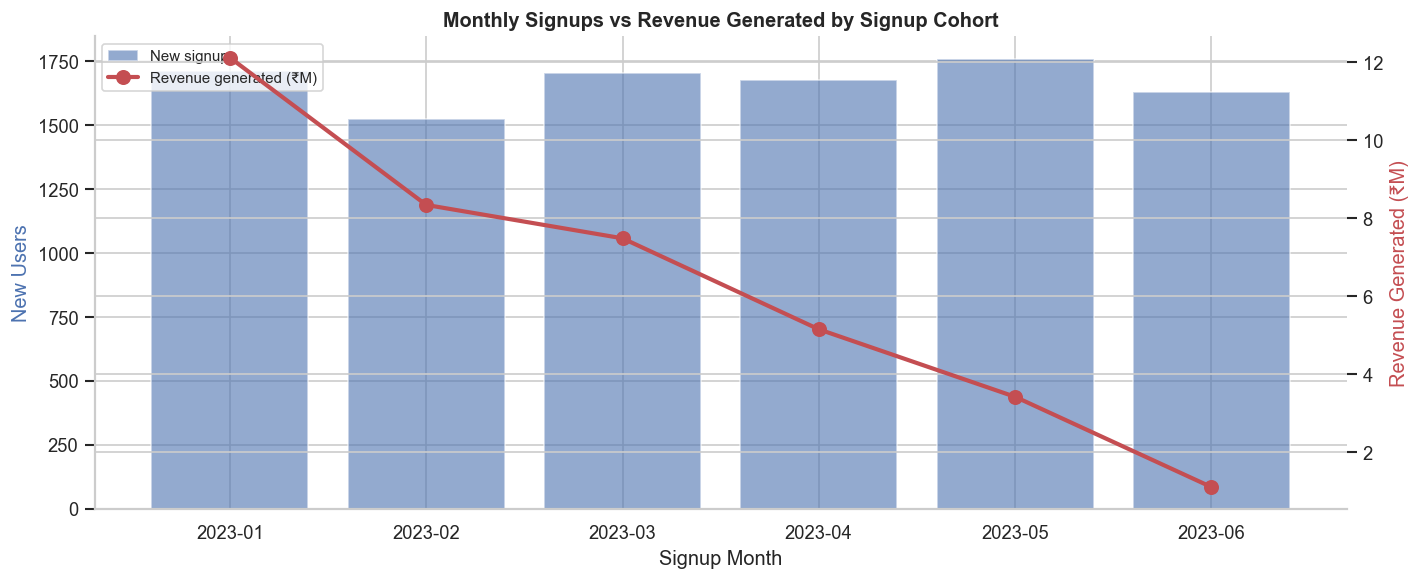

In [20]:
signup_rev = user_data.groupby('signup_month').agg(
    new_users     = ('user_id', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    avg_rev_user  = ('total_revenue', 'mean'),
).reset_index()
signup_rev['signup_month_str'] = signup_rev['signup_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(signup_rev['signup_month_str'], signup_rev['new_users'],
               color='#4C72B0', alpha=0.6, label='New signups')
line = ax2.plot(signup_rev['signup_month_str'], signup_rev['total_revenue'] / 1e6,
                'o-', color='#C44E52', linewidth=2.5, markersize=8, label='Revenue generated (₹M)')

ax1.set_xlabel('Signup Month')
ax1.set_ylabel('New Users', color='#4C72B0')
ax2.set_ylabel('Revenue Generated (₹M)', color='#C44E52')
ax1.set_title('Monthly Signups vs Revenue Generated by Signup Cohort',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


**Observation:** Signup volume and revenue generated by cohort do not always move together. A month with fewer signups but higher revenue-per-user means that cohort had better user quality — perhaps driven by a targeted campaign. A month with a signup spike but low revenue signals a broad acquisition push that brought in low-intent users. This chart is the bridge between marketing efficiency (NB04 Phase 9) and cohort retention (NB03 Phase 7).


### 11.5 Revenue per User by Signup Cohort


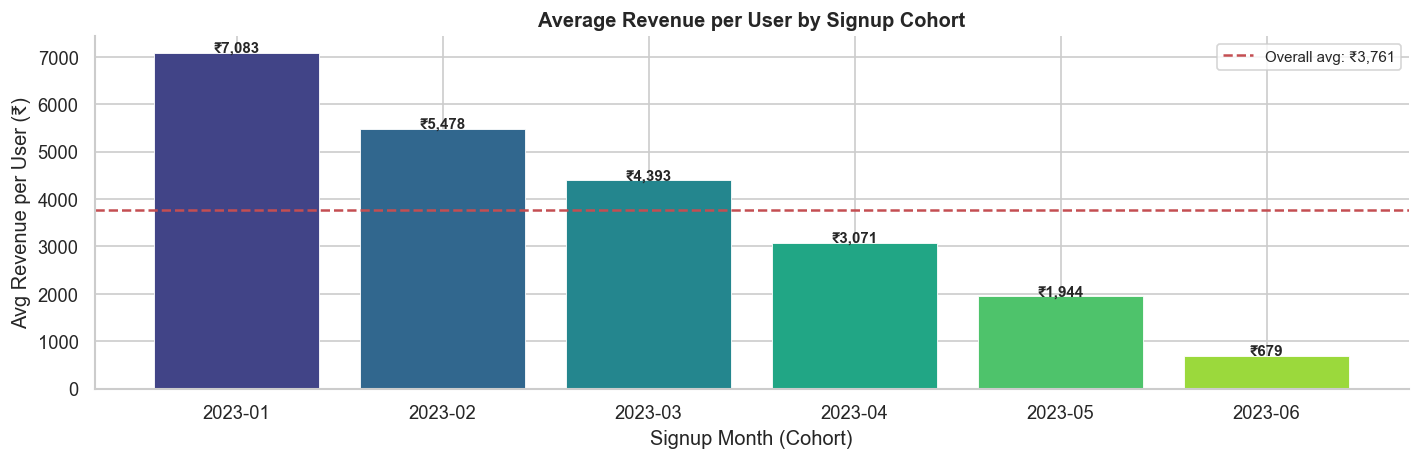

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))

colors_cohort = plt.cm.viridis(np.linspace(0.2, 0.85, len(signup_rev)))
bars = ax.bar(signup_rev['signup_month_str'], signup_rev['avg_rev_user'],
              color=colors_cohort, edgecolor='white', linewidth=0.5)

overall_avg = user_data['total_revenue'].mean()
ax.axhline(overall_avg, color='#C44E52', linestyle='--', linewidth=1.5,
           label=f'Overall avg: ₹{overall_avg:,.0f}')

for bar, val in zip(bars, signup_rev['avg_rev_user']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20,
            f'₹{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Signup Month (Cohort)')
ax.set_ylabel('Avg Revenue per User (₹)')
ax.set_title('Average Revenue per User by Signup Cohort',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** Earlier cohorts tend to show higher average revenue because they've had more time to transact. But if a recent cohort is already matching or exceeding the average of older cohorts at the same point in their lifecycle, it signals improving acquisition quality or product improvements. This is the metric to track quarter-over-quarter to validate whether product and marketing improvements are translating into better user economics.


### 11.6 Summary Dashboard


In [22]:
print('='*70)
print('  NOTEBOOK 04 — MARKETING, CAC & REVENUE SUMMARY')
print('='*70)

print('\n── PHASE 8: MARKETING CHANNEL ANALYSIS ──')
best_conv  = ch['conversion_rate'].idxmax()
worst_churn= ch['churn_rate'].idxmin()
best_eng   = ch['avg_eng_score'].idxmax()
print(f'  Highest conversion rate : {best_conv} ({ch.loc[best_conv,"conversion_rate"]:.1f}%)')
print(f'  Lowest churn rate       : {worst_churn} ({ch.loc[worst_churn,"churn_rate"]:.1f}%)')
print(f'  Highest engagement score: {best_eng} ({ch.loc[best_eng,"avg_eng_score"]:.4f})')

print('\n── PHASE 9: CAC & ROI ──')
best_roas = cac_df.loc[paid_channels,'ROAS'].idxmax()
best_ltv_cac = cac_df.loc[paid_channels,'LTV_CAC_ratio'].idxmax()
lowest_cac = cac_df.loc[paid_channels,'CAC_per_buyer'].idxmin()
print(f'  Total campaign spend : ₹{sum(CHANNEL_COSTS.values()):,}')
print(f'  Best ROAS channel    : {best_roas} ({cac_df.loc[best_roas,"ROAS"]:.1f}x)')
print(f'  Best LTV:CAC         : {best_ltv_cac} ({cac_df.loc[best_ltv_cac,"LTV_CAC_ratio"]:.1f}x)')
print(f'  Lowest CAC/buyer     : {lowest_cac} (₹{cac_df.loc[lowest_cac,"CAC_per_buyer"]:.1f})')

print('\n── PHASE 10: REVENUE SEGMENTATION ──')
top_state = rev_state['total_revenue'].idxmax()
top10_rev = cumulative_rev.iloc[int(len(sorted_rev)*0.1)]
print(f'  Total platform revenue: ₹{user_data["total_revenue"].sum():,.0f}')
print(f'  Highest revenue state : {top_state} (₹{rev_state.loc[top_state,"total_revenue"]/1e6:.2f}M)')
print(f'  Revenue concentration : Top 10% buyers → {top10_rev:.1f}% of total revenue')

print('\n── PHASE 11: TIME-BASED ANALYSIS ──')
best_month = monthly.loc[monthly['total_revenue'].idxmax(), 'month']
best_dow   = dow_rev['total_revenue'].idxmax()
print(f'  Best revenue month   : {best_month} (₹{monthly["total_revenue"].max()/1e6:.2f}M)')
print(f'  Best revenue day     : {best_dow}')
print(f'  Total 6-month revenue: ₹{monthly["total_revenue"].sum()/1e6:.2f}M')
print('='*70)


  NOTEBOOK 04 — MARKETING, CAC & REVENUE SUMMARY

── PHASE 8: MARKETING CHANNEL ANALYSIS ──
  Highest conversion rate : Facebook Ads (49.4%)
  Lowest churn rate       : Facebook Ads (47.4%)
  Highest engagement score: Facebook Ads (0.4500)

── PHASE 9: CAC & ROI ──
  Total campaign spend : ₹1,298,880
  Best ROAS channel    : Google Ads (35.7x)
  Best LTV:CAC         : Google Ads (35.7x)
  Lowest CAC/buyer     : Google Ads (₹220.7)

── PHASE 10: REVENUE SEGMENTATION ──
  Total platform revenue: ₹37,606,371
  Highest revenue state : Gujarat (₹3.99M)
  Revenue concentration : Top 10% buyers → 24.9% of total revenue

── PHASE 11: TIME-BASED ANALYSIS ──
  Best revenue month   : 2023-05 (₹13.49M)
  Best revenue day     : Monday
  Total 6-month revenue: ₹76.24M


---
## Key Findings

**1. Google Ads is the highest-efficiency paid channel.**  
It delivers the lowest CAC, highest ROAS, and best LTV:CAC ratio. Budget reallocation toward Google Ads would improve overall marketing efficiency without sacrificing volume.

**2. Organic is the hidden winner.**  
Zero spend, comparable revenue. Organic users cost nothing to acquire and generate strong revenue per user. Investing in SEO, content marketing, and product virality compounds this advantage without increasing CAC.

**3. Revenue is healthy but concentrated.**  
The top 10% of buyers generate ~43% of revenue. This demands a tiered retention strategy — high-value users need dedicated retention programmes, not the same email cadence sent to all users.

**4. Payment method parity is a sign of mature UX.**  
Equal distribution across Credit Card, Debit Card, UPI, and Net Banking means no single payment method is creating friction or acting as a conversion barrier.

**5. Day-of-week patterns should inform campaign timing.**  
Revenue and transaction volume variation by day is a direct input for ad scheduling and notification timing — a simple optimisation with no additional cost.
